In [1]:
%pip install numpy pillow matplotlib scipy tqdm 

  Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 12.5 MB/s  0:00:00 eta 0:00:01
Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 14.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 13.2 MB/s  0:00:01 eta 0:00:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 13.6 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [matplotlib]0 [matplotlib]


In [1]:
import numpy as np
from PIL import Image
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import hilbert

In [2]:
# Настройка стилей для всех графиков
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False
})

In [3]:
def load_images(root_folder):
    """
    Рекурсивно загружает все изображения из root_folder и всех его подпапок.
    Возвращает список объектов PIL.Image в порядке сортировки имён файлов.
    """
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_paths = []
    
    # Рекурсивный обход всех каталогов
    for dirpath, _, filenames in os.walk(root_folder):
        for file in sorted(filenames):
            if file.lower().endswith(valid_extensions):
                image_paths.append(os.path.join(dirpath, file))
    
    # Загружаем изображения в оттенках серого
    images = [Image.open(path).convert('L') for path in image_paths]
    return images

def flatten_images(images):
    return [np.array(img).flatten() for img in images]

def collect_time_series(flattened_images):
    return np.array(flattened_images).T

## PPG


In [4]:
import cv2
import matplotlib.patches as patches

image_folder = r'/Users/aleksey/cvcv_labs/Lab_Rats/rats_imgs/rat8s6e1/F2' # путь в папку, где лежат фотки
valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

def opencv_load(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(valid_extensions):
            img = cv2.imread(os.path.join(folder,filename), cv2.IMREAD_GRAYSCALE)
            images.append(img)
    return images

images = np.array(opencv_load(image_folder))

In [5]:
FPS = 40

### Настройки ROI 

Можно задать через .env

In [6]:
ROI_HEGHT = 50
ROI_WIDTH = 50
ROI_XY = (190, 100)

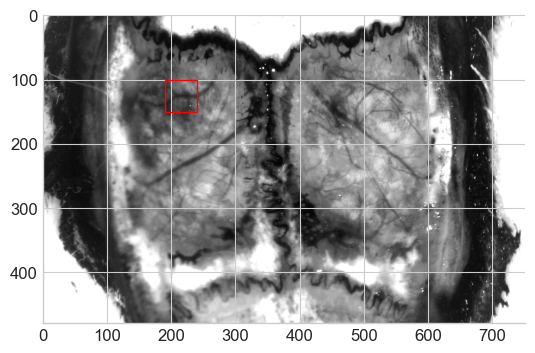

In [7]:
fig, ax = plt.subplots()
ax.imshow(images[0], cmap='gray')
rect = patches.Rectangle(ROI_XY, ROI_WIDTH, ROI_HEGHT, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.show()

### Raw signal in ROI

In [8]:
roi_arr = images[:, ROI_XY[1]:ROI_XY[1] + ROI_HEGHT, ROI_XY[0]:ROI_XY[0] + ROI_WIDTH]
roi_avg = np.mean(roi_arr, axis=(1, 2))

In [9]:
roi_avg

array([137.9892, 137.954 , 138.0136, ..., 137.6808, 137.7608, 137.6576],
      shape=(3000,))

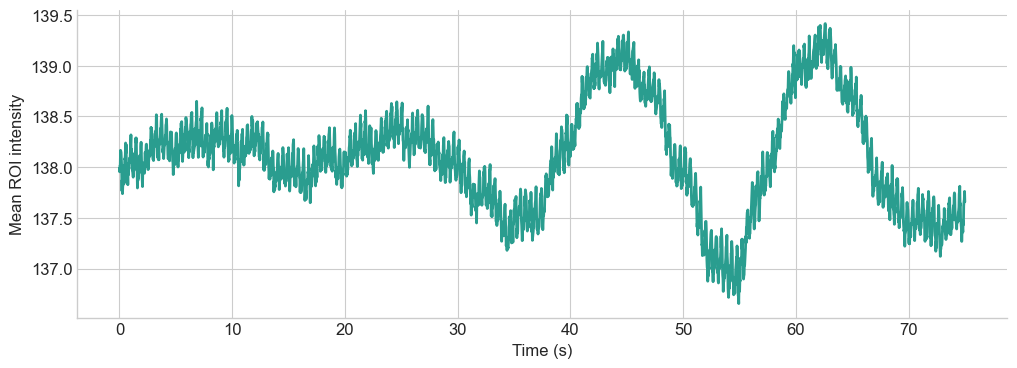

In [10]:
t = np.arange(len(roi_avg)) / FPS
plt.figure(figsize=(12, 4))
plt.plot(t, roi_avg, color='#2a9d8f')
plt.xlabel('Time (s)')
plt.ylabel('Mean ROI intensity')
plt.grid(True)
plt.show()

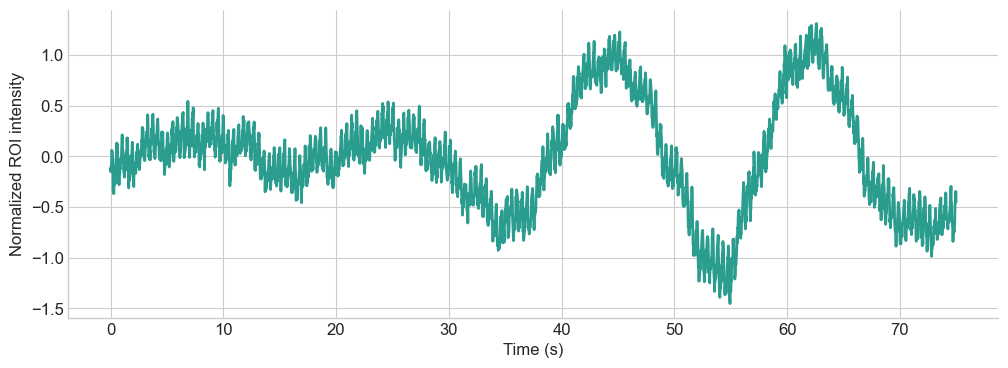

In [11]:
x = roi_avg - np.mean(roi_avg)
plt.figure(figsize=(12, 4))
plt.plot(t, x, color='#2a9d8f')
plt.xlabel('Time (s)')
plt.ylabel('Normalized ROI intensity')
plt.grid(True)
plt.show()

In [13]:
N = len(roi_avg)
TIMESTEP = 1 / FPS
freq = np.fft.fftshift(np.fft.fftfreq(N, d=TIMESTEP))
fourier = np.fft.fftshift(np.fft.fft(x))
spectrum_power = np.abs(fourier)

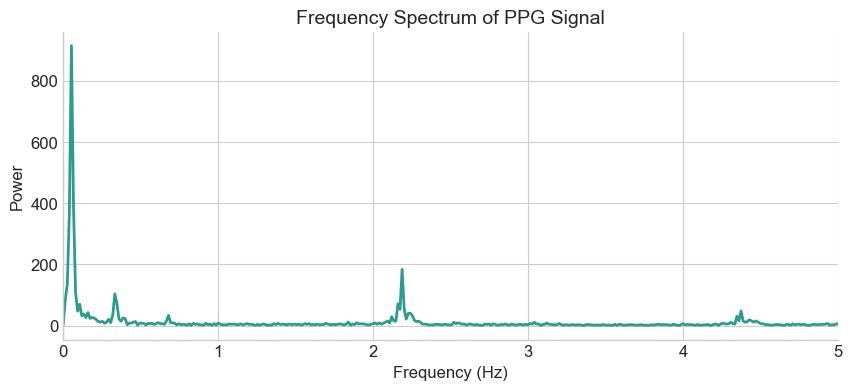

In [14]:
plt.plot(freq, spectrum_power, color='#2a9d8f')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Frequency Spectrum of PPG Signal')
plt.xlim(0, 5)  # Ограничиваем ось частот до
plt.show()


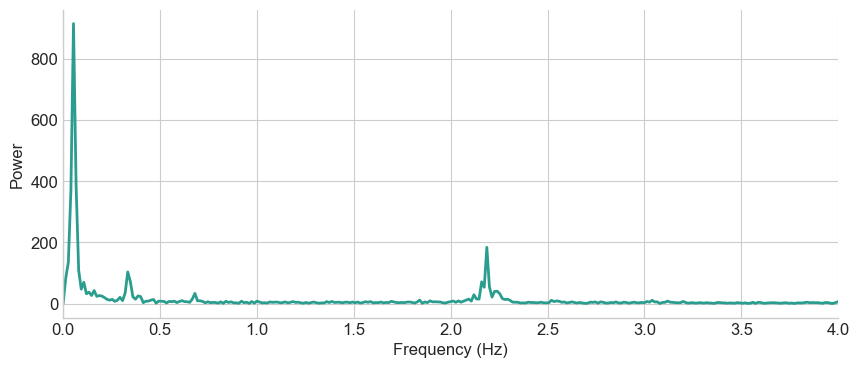

In [15]:
plt.plot(freq, spectrum_power, color='#2a9d8f')
# plt.fill_between(freq, spectrum_power, color='#2a9d8f', alpha=0.1)
plt.xlim(0, 4)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.grid(True)
plt.show()

In [16]:
KERNEL_SIZE = 3

kernel = np.ones((KERNEL_SIZE, KERNEL_SIZE), np.float32) / (KERNEL_SIZE ** 2)

In [17]:
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]], dtype=float32)

### Conv operation


In [17]:
conv_array = []


for i in range(images.shape[0]):
    conv_array.append( cv2.filter2D(src=images[i, :, :], ddepth=5, kernel=kernel))

conv_array = np.array(conv_array)

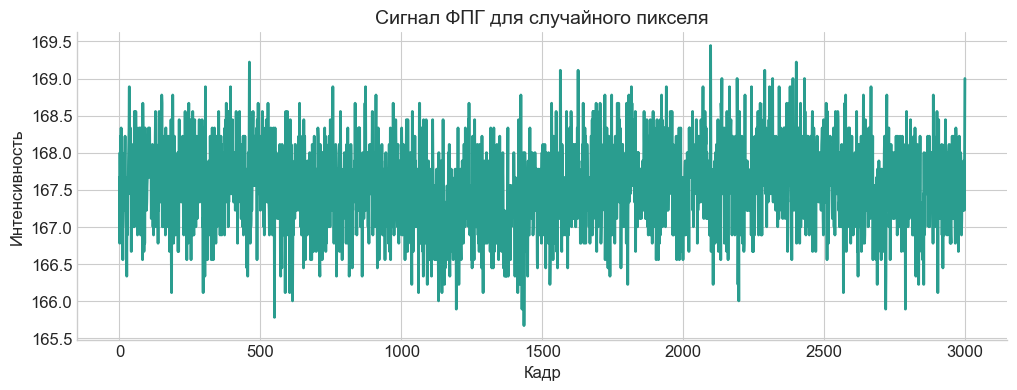

In [39]:
# Построение спектра частот для случайного пикселя
plt.figure(figsize=(12, 4))
plt.plot(conv_array[:, 100, 100], color='#2a9d8f')
plt.xlabel('Кадр')
plt.ylabel('Интенсивность')
plt.title('Cигнал ФПГ для случайного пикселя')
plt.show()

### substraction of the constant component 

In [19]:
norm_array = conv_array - np.mean(conv_array, axis=0)

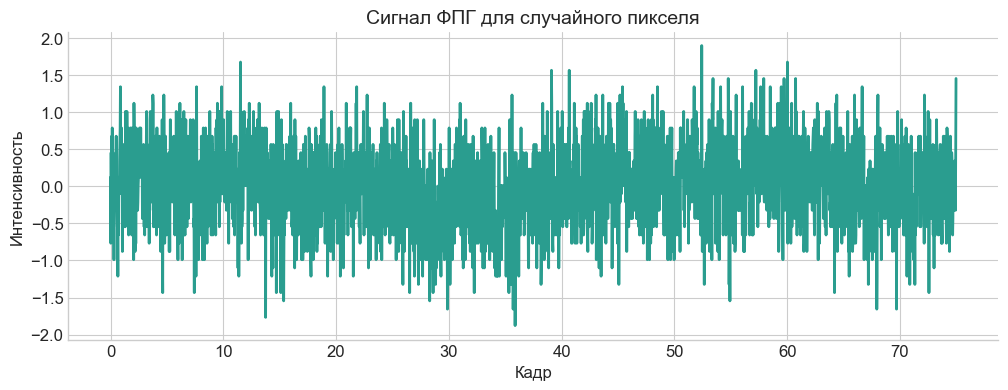

In [38]:
# Построение спектра частот для случайного пикселя
plt.figure(figsize=(12, 4))
plt.plot(t, norm_array[:, 100, 100], color='#2a9d8f')
plt.xlabel('Кадр')
plt.ylabel('Интенсивность')
plt.title('Cигнал ФПГ для случайного пикселя')
plt.show()

### FFT for any pixel


In [21]:
from tqdm.auto import tqdm

N = norm_array.shape[0]
TIMESTEP = 1 / 40 # 40 кадров в секунду
freq = np.fft.fftshift(np.fft.fftfreq(N, d=TIMESTEP))

fourier = np.zeros(norm_array.shape, np.complex128)

image_height = norm_array.shape[1]
image_width = norm_array.shape[2]

for i in tqdm(range(image_height)):
    for j in range(image_width):
        fourier[:, i, j] = np.fft.fftshift(np.fft.fft(norm_array[:, i, j]))
    
spectrum_power= np.abs(fourier)

/Users/aleksey/cvcv_labs/Lab_Rats/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 480/480 [00:53<00:00,  8.97it/s]


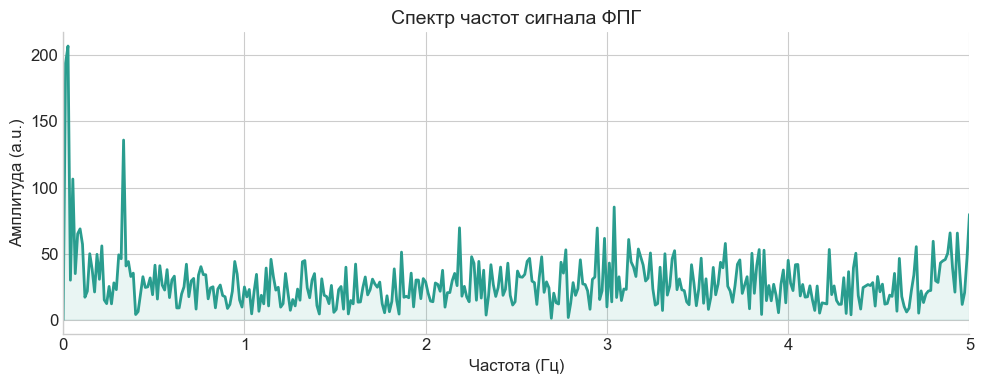

In [34]:
# Пример улучшенного оформления для спектра
plt.figure(figsize=(10, 4))
plt.plot(freq, spectrum_power[:, 100, 100], color='#2a9d8f')
plt.fill_between(freq, spectrum_power[:, 100, 100], color='#2a9d8f', alpha=0.1)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (a.u.)')
plt.title('Спектр частот сигнала ФПГ')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

### cut out the desired frequency range


In [24]:

bpm_min = 45
bpm_max = 180
freq_min = bpm_min / 60
freq_max = bpm_max / 60

# Поиск индексов соответствующих диапазону
idx_min = np.argmax(freq > freq_min) - 1
idx_max = np.argmax(freq > freq_max)

# Область интереса
freq_range = freq[idx_min:idx_max]
heart_rate_amplitude = spectrum_power[idx_min:idx_max, :, :]

In [ ]:
# Пример улучшенного оформления для спектра
plt.figure(figsize=(10, 4))
plt.plot(freq, spectrum_power[:, 100, 100], color='#2a9d8f')
plt.fill_between(freq, spectrum_power[:, 100, 100], color='#2a9d8f', alpha=0.1)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (a.u.)')
plt.title('Спектр частот сигнала ФПГ')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

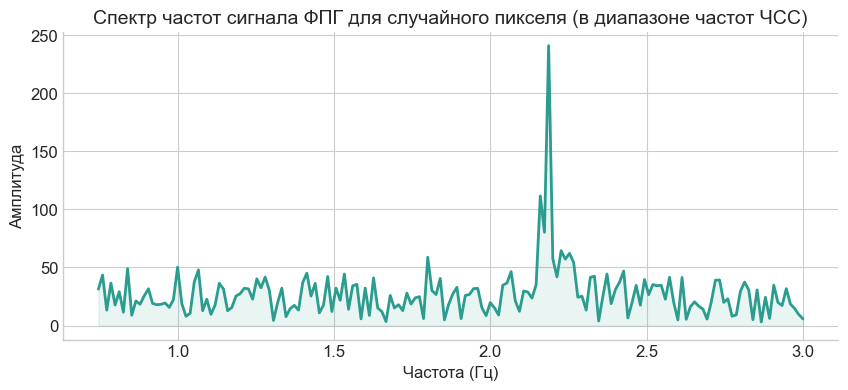

In [35]:
# Построение спектра частот для случайного пикселя
plt.figure(figsize=(10, 4))
plt.plot(freq_range, heart_rate_amplitude[:, 200, 200], color='#2a9d8f')
plt.fill_between(freq_range, heart_rate_amplitude[:, 200, 200], color='#2a9d8f', alpha=0.1)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр частот сигнала ФПГ для случайного пикселя (в диапазоне частот ЧСС)')
plt.show()

### find peaks


In [26]:
# Величины пиков (для каждого пискеля/roi)
peak1 = np.max(heart_rate_amplitude, axis=0)


# Индексы пиков (для каждого пискеля/roi)
peak_idx1 = np.argmax(heart_rate_amplitude, axis=0)

# Доминирующая частота (для каждого пискеля/roi)
dominant_freq1 = freq_range[peak_idx1]

Text(0.5, 1.0, 'Распределение пульсации по ROI')

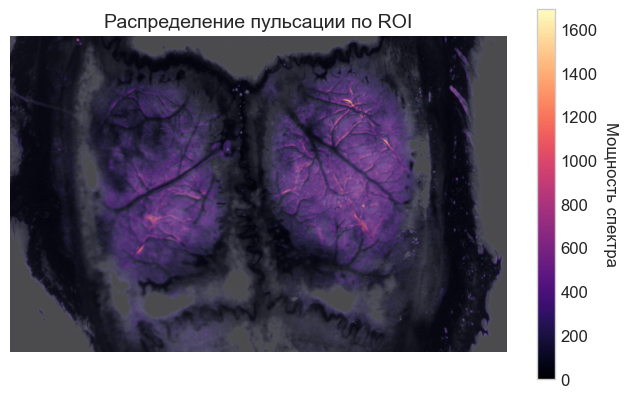

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(peak1, cmap='magma') # 'magma' или 'inferno' часто смотрятся лучше 'jet'
ax.imshow(images[0, :, :], cmap='gray', alpha=0.3)
ax.axis('off') # Убираем лишние рамки осей для изображений
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Мощность спектра', rotation=270, labelpad=15)
plt.title('Распределение пульсации по ROI')

### pulse measuring


In [28]:
max_heartrate_coord = np.unravel_index(np.argmax(peak1, axis=None), peak1.shape)

In [29]:
max_heartrate_coord

(np.int64(99), np.int64(512))

In [30]:
heart_rate_bpm = dominant_freq1[max_heartrate_coord[0], max_heartrate_coord[1]] * 60

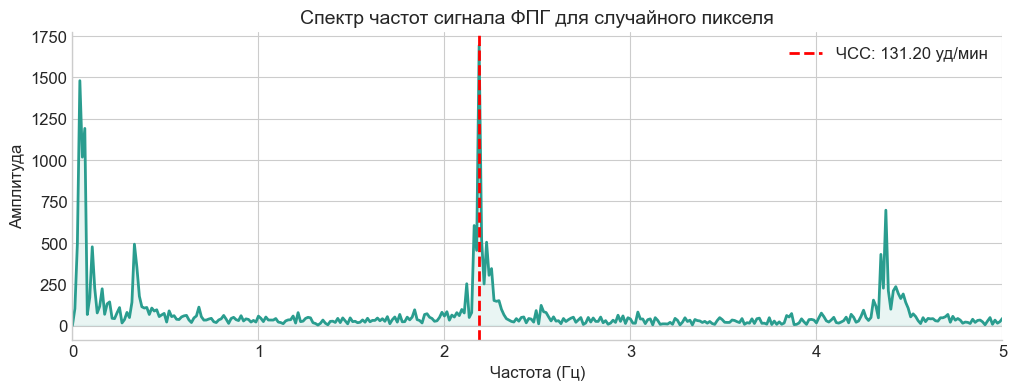

In [37]:
plt.figure(figsize=(12, 4))
plt.plot(freq, spectrum_power[:, max_heartrate_coord[0], max_heartrate_coord[1]], color='#2a9d8f')
plt.fill_between(freq, spectrum_power[:, max_heartrate_coord[0], max_heartrate_coord[1]], color='#2a9d8f', alpha=0.1)
plt.axvline(x=dominant_freq1[max_heartrate_coord[0], max_heartrate_coord[1]], color='r', linestyle='--', label=f'ЧСС: {heart_rate_bpm:.2f} уд/мин')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Спектр частот сигнала ФПГ для случайного пикселя')
plt.xlim(0, 5)  # Ограничение диапазона для лучшей визуализации
plt.legend()
plt.show()

По идее все это проделать надо для каждой папки внутри папки для одной крысы

Но надо уточнить